In [2]:
import json

notebook_path = "FedLEASE_reproduction_step3.ipynb"

with open(notebook_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

# Remove broken widget metadata
nb.get("metadata", {}).pop("widgets", None)

with open(notebook_path, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1, ensure_ascii=False)

print("Fixed:", notebook_path)

Fixed: FedLEASE_reproduction_step3.ipynb


In [ ]:
pip install transformers datasets scikit-learn seaborn

In [ ]:
import torch
from transformers import RobertaModel, RobertaTokenizer, RobertaForSequenceClassification
from datasets import load_dataset
from torch.utils.data import DataLoader
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
import copy
import random

In [ ]:
# ─── Model configuration ───────────────────────────────────────────────────
MODEL_NAME = 'roberta-large'
HIDDEN_SIZE = 1024   # roberta-base: 768, roberta-large: 1024
NUM_LAYERS = 24      # roberta-base: 12,  roberta-large: 24
RANK = 4
LORA_ALPHA = 1.0
BATCH_SIZE = 128
NUM_EPOCHS = 2
LR = 3e-4
NUM_CLIENTS = 4
SEED = 2026
MAX_SAMPLES_PER_CLIENT = None


torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)
  device = "cuda"
else:
  device ="cpu"


print(f"Device : {device}")

Device : cuda


In [ ]:
# Load RoBERTa tokenizer and model from HuggingFace
# The tokenizer converts raw text to token IDs
# The model weights are frozen - only LoRA parameters will be trained
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)
#model = RobertaModel.from_pretrained(MODEL_NAME)

model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
).to(device)

# Freeze all pretrained model parameters.
# We only train the manually defined LoRA parameters.
for param in model.parameters():
    param.requires_grad = False

# Keep the classifier frozen too, to make the comparison focus on LoRA.
# This is closer to the paper, where the classification head is frozen after initialization.
for param in model.classifier.parameters():
    param.requires_grad = False

# Print model config to verify architecture
print(model.config)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaConfig {
  "add_cross_attention": false,
  "architectures": [
    "RobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 1024,
  "initializer_range": 0.02,
  "intermediate_size": 4096,
  "is_decoder": false,
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "roberta",
  "num_attention_heads": 16,
  "num_hidden_layers": 24,
  "pad_token_id": 1,
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 50265
}



In [ ]:
# Load SST-2 dataset from the GLUE benchmark
# SST-2 is a binary sentiment classification task (positive/negative)
dataset_sst2 = load_dataset('glue', 'sst2')
print(dataset_sst2)
print(dataset_sst2['train'][0])

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})
{'sentence': 'hide new secretions from the parental units ', 'label': 0, 'idx': 0}


In [ ]:
# Load QNLI dataset from the GLUE benchmark
# QNLI is a question-answer inference task: given a question and a sentence,
# determine whether the sentence contains the answer to the question
dataset_qnli = load_dataset('glue', 'qnli')
print(dataset_qnli)
print(dataset_qnli['train'][0])

DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
})
{'question': 'When did the third Digimon series begin?', 'sentence': 'Unlike the two seasons before it and most of the seasons that followed, Digimon Tamers takes a darker and more realistic approach to its story featuring Digimon who do not reincarnate after their deaths and more complex character development in the original Japanese.', 'label': 1, 'idx': 0}


In [ ]:
def tokenize_sst2(examples):
    """
    Tokenize SST-2 examples.
    SST-2 has a single text input (sentence).
    """
    return tokenizer(
        examples['sentence'],
        truncation=True,      # Truncate sequences longer than max_length
        max_length=128,       # Maximum sequence length (paper uses 128)
        padding='max_length'  # Pad shorter sequences to max_length
    )

def tokenize_qnli(examples):
    """
    Tokenize QNLI examples.
    QNLI has two text inputs (question + sentence) that are concatenated
    by the tokenizer with a separator token.
    """
    return tokenizer(
        examples['question'],
        examples['sentence'],
        truncation=True,
        max_length=128,
        padding='max_length'
    )

In [ ]:
# Apply tokenization to both datasets using batched processing for efficiency
# This adds 'input_ids' and 'attention_mask' columns to each dataset
dataset_sst2 = dataset_sst2.map(tokenize_sst2, batched=True)
dataset_qnli = dataset_qnli.map(tokenize_qnli, batched=True)

# Verify that tokenization columns were added correctly
print(dataset_sst2['train'].column_names)

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

Map:   0%|          | 0/104743 [00:00<?, ? examples/s]

Map:   0%|          | 0/5463 [00:00<?, ? examples/s]

Map:   0%|          | 0/5463 [00:00<?, ? examples/s]

['sentence', 'label', 'idx', 'input_ids', 'attention_mask']


In [ ]:
# Remove unnecessary columns and keep only: input_ids, attention_mask, label
# Then convert datasets to PyTorch tensor format
dataset_sst2 = dataset_sst2.remove_columns(['idx', 'sentence'])
dataset_sst2 = dataset_sst2.with_format('torch')

dataset_qnli = dataset_qnli.remove_columns(['idx', 'question', 'sentence'])
dataset_qnli = dataset_qnli.with_format('torch')

# Verify that only the necessary columns remain
print(dataset_sst2['train'].column_names)
print(dataset_qnli['train'].column_names)

['label', 'input_ids', 'attention_mask']
['label', 'input_ids', 'attention_mask']


In [ ]:
def partition_dataset(dataset, num_clients, max_samples_per_client=None):
    """
    Randomly partition a dataset into equal parts for each client.
    Each client receives a non-overlapping subset of the data.

    Args:
        dataset: HuggingFace dataset to partition
        num_clients: number of clients to split the data among

    Returns:
        list of dataset subsets, one per client
    """
    n = len(dataset)

    # Randomly shuffle indices to ensure each client gets a random subset
    indices = np.random.permutation(n)
    if max_samples_per_client is not None:
      total_needed = num_clients * max_samples_per_client
      indices = indices[:total_needed]
      size = max_samples_per_client
    else:
      # Size of each client's partition
      size = n // num_clients

    partitions = []

    for i in range(num_clients):
        # Compute start and end indices for client i
        start = i * size
        end = (i + 1) * size
        partitions.append(dataset.select(indices[start:end]))

    return partitions

In [ ]:
# Partition SST-2 among clients 0 and 1, QNLI among clients 2 and 3
# This simulates the heterogeneous federated learning setting from the paper:
# clients 0-1 share the same task (SST-2), clients 2-3 share a different task (QNLI)
sst2_partitions = partition_dataset(dataset_sst2['train'], num_clients=2, max_samples_per_client=MAX_SAMPLES_PER_CLIENT)
qnli_partitions = partition_dataset(dataset_qnli['train'], num_clients=2, max_samples_per_client=MAX_SAMPLES_PER_CLIENT)

# Map each client ID to its local dataset
client_datasets = {
    0: sst2_partitions[0],  # SST-2
    1: sst2_partitions[1],  # SST-2
    2: qnli_partitions[0],  # QNLI
    3: qnli_partitions[1],  # QNLI
}

# Verify partition sizes
for cid, ds in client_datasets.items():
    print(f"Client {cid} : {len(ds)} examples")

Client 0 : 33674 examples
Client 1 : 33674 examples
Client 2 : 52371 examples
Client 3 : 52371 examples


In [ ]:
# Create a DataLoader for each client
# batch_size=32 (paper uses 128, reduced here for Colab T4 memory constraints)
# shuffle=True to ensure random ordering of samples during training
client_loaders = {}
for cid, ds in client_datasets.items():
    client_loaders[cid] = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)

# Verify number of batches per client
print(f"Number of batches per client:")
for cid, loader in client_loaders.items():
    print(f"  Client {cid} : {len(loader)} batches")

Number of batches per client:
  Client 0 : 264 batches
  Client 1 : 264 batches
  Client 2 : 410 batches
  Client 3 : 410 batches


In [ ]:
import math

def initialize_lora_params(rank=RANK):
    """
    Initialize LoRA parameters (A and B matrices) for all query and value
    projections across all layers of RoBERTa.

    Returns a dictionary: layer_name -> {'A': tensor, 'B': tensor}
    """
    lora_params = {}

    for layer_idx in range(NUM_LAYERS):
        for proj in ['query', 'value']:
            key = f'layer_{layer_idx}_{proj}'

            # A : shape (rank, HIDDEN_SIZE), initialized with kaiming uniform
            A = torch.empty(RANK, HIDDEN_SIZE)
            torch.nn.init.kaiming_uniform_(A, a=math.sqrt(5))

            # B : shape (HIDDEN_SIZE, rank), initialized to zero so that
            # the LoRA delta B@A = 0 at the start of training,
            # leaving the pretrained model unchanged (paper Section 3.1)
            B = torch.zeros(HIDDEN_SIZE, RANK)

            lora_params[key] = {
                'A': A.to(device),
                'B': B.to(device)
            }

    return lora_params

In [ ]:
# Verify LoRA parameter initialization for one client
# Expected: NUM_LAYERS * 2 layers (query and value projections)
# A shape: (RANK, HIDDEN_SIZE)
# B shape: (HIDDEN_SIZE, RANK)
lora_params_client0 = initialize_lora_params(rank=RANK)
print(f"Number of LoRA layers: {len(lora_params_client0)}")
print(f"Shape of A: {lora_params_client0['layer_0_query']['A'].shape}")
print(f"Shape of B: {lora_params_client0['layer_0_query']['B'].shape}")

Number of LoRA layers: 48
Shape of A: torch.Size([4, 1024])
Shape of B: torch.Size([1024, 4])


In [ ]:
# Initialize independent LoRA parameters for each client
# Each client starts with the same initialization but will diverge during local training
# reflecting their different task distributions (SST-2 vs QNLI)
initial_lora_params = initialize_lora_params(rank=RANK)

client_lora_params = {
    cid: copy.deepcopy(initial_lora_params)
    for cid in range(NUM_CLIENTS)
}

In [ ]:
def lora_forward(model, input_ids, attention_mask, lora_params, rank=RANK, lora_alpha=LORA_ALPHA):
    """
    Forward pass through RobertaForSequenceClassification with LoRA deltas
    applied to the query and value projections.

    The model already includes the classification head, so this function
    directly returns the classification logits.
    """
    scaling = lora_alpha / rank
    hooks = []

    def make_hook(key):
        def hook(module, input, output):
            # input[0] shape: (batch, seq_len, hidden_size)
            A = lora_params[key]['A']
            B = lora_params[key]['B']

            # LoRA delta: x @ A.T @ B.T
            lora_delta = input[0] @ A.T @ B.T * scaling

            return output + lora_delta

        return hook

    # Register LoRA hooks on query and value projections
    for layer_idx in range(NUM_LAYERS):
        for proj in ['query', 'value']:
            key = f'layer_{layer_idx}_{proj}'

            # With RobertaForSequenceClassification, the backbone is model.roberta
            layer = model.roberta.encoder.layer[layer_idx].attention.self

            hook = getattr(layer, proj).register_forward_hook(make_hook(key))
            hooks.append(hook)

    # Forward pass through the full sequence classification model
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    # Remove hooks after the forward pass
    for hook in hooks:
        hook.remove()

    # Return logits directly
    return outputs.logits

In [ ]:
# Test lora_forward with a small batch
# Expected output shape: (batch_size, num_labels)
model.eval()

batch = next(iter(client_loaders[0]))
input_ids = batch['input_ids'].to(device)
attention_mask = batch['attention_mask'].to(device)

with torch.no_grad():
    logits = lora_forward(model, input_ids, attention_mask, client_lora_params[0])

print(f"Logits shape: {logits.shape}")

Logits shape: torch.Size([128, 2])


In [ ]:
import torch.nn as nn

class ClassificationHead(nn.Module):
    """
    Simple classification head on top of RoBERTa.
    Takes the [CLS] token representation and predicts the class.

    The [CLS] token (index 0) aggregates the full sequence representation
    and is standard practice for classification tasks with BERT-based models.
    """
    def __init__(self, hidden_size=HIDDEN_SIZE, num_classes=2):
        super().__init__()
        # Linear layer mapping from HIDDEN_SIZE to number of classes (2)
        self.linear = nn.Linear(hidden_size, num_classes)

    def forward(self, roberta_output):
        # Extract [CLS] token (index 0) from all sequences in the batch
        # Shape: (batch_size, HIDDEN_SIZE)
        cls_token = roberta_output.last_hidden_state[:, 0, :]
        # Shape: (batch_size, num_classes)
        return self.linear(cls_token)

# Each client has its own classification head trained on its local data
client_heads = {
    cid: ClassificationHead().to(device) for cid in range(NUM_CLIENTS)
}

print(f"Number of classification heads: {len(client_heads)}")

Number of classification heads: 4


In [ ]:
def train_client(model, lora_params, loader, num_epochs=NUM_EPOCHS, lr=LR):
    """
    Train one client locally for num_epochs epochs.

    Only the manual LoRA parameters A and B are updated.
    The RoBERTa backbone and its classification head stay frozen.
    """
    trainable_params = []

    # Convert A and B tensors to nn.Parameters so they can be optimized
    for key in lora_params:
        if not isinstance(lora_params[key]['A'], nn.Parameter):
            lora_params[key]['A'] = nn.Parameter(lora_params[key]['A'])
        if not isinstance(lora_params[key]['B'], nn.Parameter):
            lora_params[key]['B'] = nn.Parameter(lora_params[key]['B'])

        trainable_params.append(lora_params[key]['A'])
        trainable_params.append(lora_params[key]['B'])

    optimizer = torch.optim.AdamW(trainable_params, lr=lr)
    criterion = nn.CrossEntropyLoss()
    loss_history = []

    model.train()

    for epoch in range(num_epochs):
        total_loss = 0.0

        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()

            # Forward pass directly returns classification logits
            logits = lora_forward(
                model=model,
                input_ids=input_ids,
                attention_mask=attention_mask,
                lora_params=lora_params
            )

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        loss_history.append(avg_loss)

        print(f"  Epoch {epoch + 1}/{num_epochs} | Loss: {avg_loss:.4f}")

    return lora_params, loss_history

In [ ]:
# Initialization phase:
# Each client independently trains its local LoRA for E=2 epochs.
# Clients 0-1 use SST-2, clients 2-3 use QNLI.
task_names = {
    0: 'SST-2',
    1: 'SST-2',
    2: 'QNLI',
    3: 'QNLI'
}

for cid in range(NUM_CLIENTS):
    print(f"Training client {cid} ({task_names[cid]})...")

    client_lora_params[cid], _ = train_client(
        model=model,
        lora_params=client_lora_params[cid],
        loader=client_loaders[cid],
        num_epochs=NUM_EPOCHS,
        lr=LR
    )

Training client 0 (SST-2)...
  Epoch 1/2 | Loss: 0.4974
  Epoch 2/2 | Loss: 0.2074
Training client 1 (SST-2)...
  Epoch 1/2 | Loss: 0.5041
  Epoch 2/2 | Loss: 0.2107
Training client 2 (QNLI)...
  Epoch 1/2 | Loss: 0.5668
  Epoch 2/2 | Loss: 0.3184
Training client 3 (QNLI)...
  Epoch 1/2 | Loss: 0.5798
  Epoch 2/2 | Loss: 0.3070


In [ ]:
def extract_layerwise_matrices(client_lora_params, matrix_type="B"):
    matrices = {}

    for cid, lora_params in client_lora_params.items():
        matrices[cid] = []

        for layer_idx in range(NUM_LAYERS):
            layer_parts = []

            for proj in ["query", "value"]:
                key = f"layer_{layer_idx}_{proj}"

                A = lora_params[key]["A"].detach().cpu()
                B = lora_params[key]["B"].detach().cpu()

                if matrix_type == "A":
                    layer_parts.append(A.flatten())
                elif matrix_type == "B":
                    layer_parts.append(B.flatten())
                elif matrix_type == "BA":
                    layer_parts.append((B @ A).flatten())

            matrices[cid].append(torch.cat(layer_parts))

    return matrices

In [ ]:
a_matrices = extract_layerwise_matrices(client_lora_params, "A")
b_matrices = extract_layerwise_matrices(client_lora_params, "B")
ba_matrices = extract_layerwise_matrices(client_lora_params, "BA")

In [ ]:
def compute_cosine_similarity(matrices, client_i, client_j):
    similarities = []

    for layer_idx in range(len(matrices[client_i])):
        x = matrices[client_i][layer_idx]
        y = matrices[client_j][layer_idx]

        sim = F.cosine_similarity(x.unsqueeze(0), y.unsqueeze(0))
        similarities.append(sim.item())

    return similarities

In [ ]:
sim_0_1 = compute_cosine_similarity(b_matrices, 0, 1)
sim_0_2 = compute_cosine_similarity(b_matrices, 0, 2)
sim_2_3 = compute_cosine_similarity(b_matrices, 2, 3)

print(f"Avg similarity client 0 vs 1 (same task SST-2): {np.mean(sim_0_1):.4f}")
print(f"Avg similarity client 0 vs 2 (different task):  {np.mean(sim_0_2):.4f}")
print(f"Avg similarity client 2 vs 3 (same task QNLI):  {np.mean(sim_2_3):.4f}")

Avg similarity client 0 vs 1 (same task SST-2): 0.4509
Avg similarity client 0 vs 2 (different task):  0.0851
Avg similarity client 2 vs 3 (same task QNLI):  0.3951


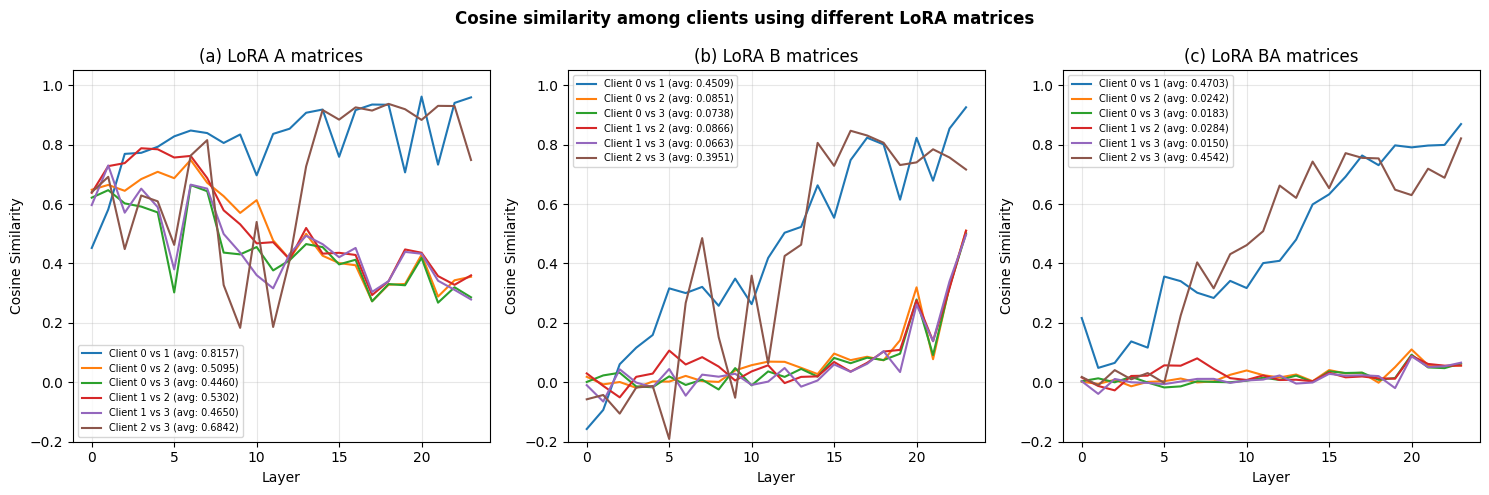

In [ ]:
pairs = [
    (0, 1),
    (0, 2),
    (0, 3),
    (1, 2),
    (1, 3),
    (2, 3),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

subtitles = ['(a)', '(b)', '(c)']
data = [
    (a_matrices,  'LoRA A matrices'),
    (b_matrices,  'LoRA B matrices'),
    (ba_matrices, 'LoRA BA matrices'),
]

for ax, (matrices, title), subtitle in zip(axes, data, subtitles):
    for (ci, cj) in pairs:
        sims = compute_cosine_similarity(matrices, ci, cj)
        avg = np.mean(sims)
        ax.plot(sims, label=f'Client {ci} vs {cj} (avg: {avg:.4f})')

    ax.set_xlabel('Layer')
    ax.set_ylabel('Cosine Similarity')
    ax.set_title(f'{subtitle} {title}')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.2, 1.05)

plt.suptitle(
    'Cosine similarity among clients using different LoRA matrices',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('figure3.png', dpi=150)
plt.show()

In [ ]:
for cid in range(NUM_CLIENTS):
    b = client_lora_params[cid]['layer_0_query']['B']
    print(f"Client {cid} | B mean: {b.mean().item():.6f} | B std: {b.std().item():.6f}")

Client 0 | B mean: 0.000209 | B std: 0.008691
Client 1 | B mean: -0.000118 | B std: 0.008737
Client 2 | B mean: -0.000199 | B std: 0.009468
Client 3 | B mean: -0.000125 | B std: 0.011420


In [ ]:
# Check gradients on B matrices
for cid in range(NUM_CLIENTS):
    b = client_lora_params[cid]['layer_0_query']['B']
    print(f"Client {cid} | B grad: {b.grad}")

Client 0 | B grad: tensor([[-4.0652e-04, -4.5138e-04,  2.2431e-04,  8.5118e-04],
        [-7.5440e-05, -7.5420e-07, -1.8579e-04,  5.5170e-04],
        [-1.2838e-03, -7.0191e-04,  6.5010e-04, -2.9789e-04],
        ...,
        [-1.0978e-03, -1.1815e-03, -6.3888e-04, -9.1804e-04],
        [-2.3876e-04, -2.0277e-04, -2.2988e-04, -6.9966e-04],
        [-1.1730e-03, -1.1542e-03,  1.1265e-04, -7.8726e-04]], device='cuda:0')
Client 1 | B grad: tensor([[ 9.9938e-04, -1.5017e-04,  4.9063e-04,  9.7862e-04],
        [-3.7477e-04, -2.4542e-05, -1.3610e-04, -3.0803e-04],
        [ 1.9343e-04, -4.7750e-04, -9.3163e-04,  4.5478e-04],
        ...,
        [ 1.1500e-03, -3.1789e-04,  1.2171e-04,  1.4121e-05],
        [ 2.4456e-04,  3.0514e-04,  5.5603e-04,  6.1279e-04],
        [ 7.4108e-04, -3.1841e-04,  2.8642e-04,  1.6878e-04]], device='cuda:0')
Client 2 | B grad: tensor([[ 3.7882e-05,  1.3111e-04, -6.4216e-05, -3.7791e-05],
        [ 1.5329e-04, -1.2959e-05, -5.1628e-05,  2.1333e-05],
        [-5.0

In [ ]:
# ── Step 2 | Cell 1 — Pairwise distance matrix between clients ───────────────
# Implements Equation (2) from the paper:
# d(i, j) = 1 - (1/|L|) * sum_l cosine_sim(B_i^l, B_j^l)

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

def compute_distance_matrix(b_matrices, num_clients, num_layers):
    dist_matrix = np.zeros((num_clients, num_clients))

    for i in range(num_clients):
        for j in range(num_clients):
            if i == j:
                continue
            layer_sims = []
            for layer_idx in range(num_layers):
                x = b_matrices[i][layer_idx]
                y = b_matrices[j][layer_idx]
                sim = F.cosine_similarity(x.unsqueeze(0), y.unsqueeze(0)).item()
                layer_sims.append(sim)
            dist_matrix[i, j] = 1.0 - np.mean(layer_sims)

    return dist_matrix


dist_matrix = compute_distance_matrix(b_matrices, NUM_CLIENTS, NUM_LAYERS)

print("Distance matrix:")
print(np.round(dist_matrix, 4))

Distance matrix:
[[0.     0.5491 0.9149 0.9262]
 [0.5491 0.     0.9134 0.9337]
 [0.9149 0.9134 0.     0.6049]
 [0.9262 0.9337 0.6049 0.    ]]


In [ ]:
# ── Step 2 | Cell 2 — Silhouette scores and optimal number of experts ─────────
# Test k = 2 ... N_CLIENTS-1 and select the k that maximizes the silhouette score.
# With 4 clients this tests k=2 and k=3; with 16 clients (Step 4) it will test up to k=8.

M_MAX = NUM_CLIENTS - 1
k_values = list(range(2, M_MAX + 1))
silhouette_scores_list = []

for k in k_values:
    clustering = AgglomerativeClustering(
        n_clusters=k,
        metric='precomputed',  # pass the distance matrix directly
        linkage='average'      # UPGMA, consistent with the paper
    )
    labels = clustering.fit_predict(dist_matrix)
    score = silhouette_score(dist_matrix, labels, metric='precomputed')
    silhouette_scores_list.append(score)
    print(f"  k={k} | silhouette={score:.4f} | labels={labels}")

# Optimal number of experts M
optimal_k = k_values[np.argmax(silhouette_scores_list)]
print(f"\nOptimal number of experts M = {optimal_k}")

# Final clustering with optimal M
final_clustering = AgglomerativeClustering(
    n_clusters=optimal_k,
    metric='precomputed',
    linkage='average'
)
final_labels = final_clustering.fit_predict(dist_matrix)

for cluster_id in range(optimal_k):
    members = [i for i, l in enumerate(final_labels) if l == cluster_id]
    print(f"  Cluster {cluster_id}: clients {members}")

  k=2 | silhouette=0.3742 | labels=[1 1 0 0]
  k=3 | silhouette=0.1997 | labels=[0 0 2 1]

Optimal number of experts M = 2
  Cluster 0: clients [2, 3]
  Cluster 1: clients [0, 1]


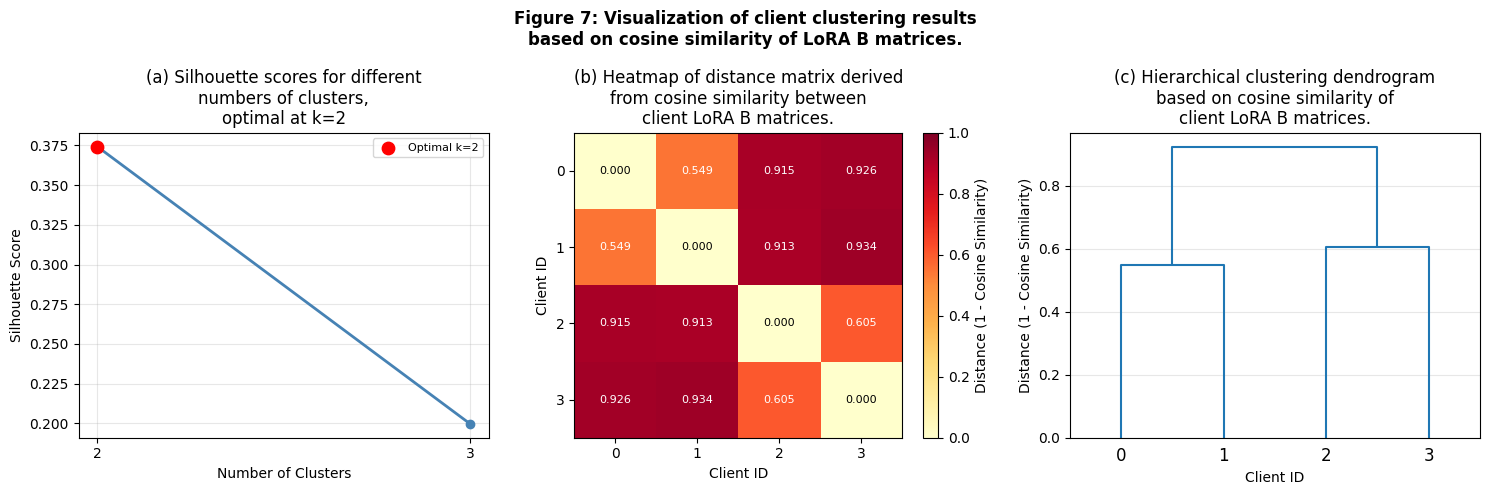

In [ ]:
# ── Step 2 | Cell 3 — Figure 7 ────────────────────────────────────────────────
# Three sub-figures:
# (a) Silhouette scores vs. number of clusters
# (b) Heatmap of the pairwise distance matrix
# (c) Hierarchical clustering dendrogram

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (a) Silhouette scores
ax = axes[0]
ax.plot(k_values, silhouette_scores_list, marker='o', color='steelblue', linewidth=2)
ax.scatter(
    [optimal_k], [silhouette_scores_list[k_values.index(optimal_k)]],
    color='red', zorder=5, s=80, label=f'Optimal k={optimal_k}'
)
ax.set_xlabel('Number of Clusters')
ax.set_ylabel('Silhouette Score')
ax.set_title(f'(a) Silhouette scores for different\nnumbers of clusters,\noptimal at k={optimal_k}')
ax.set_xticks(k_values)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (b) Heatmap of the distance matrix
ax = axes[1]
im = ax.imshow(dist_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Distance (1 - Cosine Similarity)')
ax.set_xticks(range(NUM_CLIENTS))
ax.set_yticks(range(NUM_CLIENTS))
ax.set_xticklabels([str(i) for i in range(NUM_CLIENTS)])
ax.set_yticklabels([str(i) for i in range(NUM_CLIENTS)])
ax.set_xlabel('Client ID')
ax.set_ylabel('Client ID')
ax.set_title('(b) Heatmap of distance matrix derived\nfrom cosine similarity between\nclient LoRA B matrices.')
for i in range(NUM_CLIENTS):
    for j in range(NUM_CLIENTS):
        ax.text(j, i, f'{dist_matrix[i, j]:.3f}', ha='center', va='center',
                fontsize=8, color='white' if dist_matrix[i, j] > 0.5 else 'black')

# (c) Dendrogram
ax = axes[2]
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method='average')
dendrogram(
    Z, ax=ax,
    labels=[str(i) for i in range(NUM_CLIENTS)],
    color_threshold=0.5 * max(Z[:, 2])
)
ax.set_xlabel('Client ID')
ax.set_ylabel('Distance (1 - Cosine Similarity)')
ax.set_title('(c) Hierarchical clustering dendrogram\nbased on cosine similarity of\nclient LoRA B matrices.')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(
    'Figure 7: Visualization of client clustering results\nbased on cosine similarity of LoRA B matrices.',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('figure7.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Step 2 | Cell 4 — LoRA expert initialization (Equation 3) ─────────────────
# Each expert is initialized by averaging the LoRA parameters of all clients
# assigned to its cluster.

def aggregate_lora_experts(client_lora_params, cluster_labels, num_experts):
    expert_params = {}

    for expert_id in range(num_experts):
        members = [cid for cid, l in enumerate(cluster_labels) if l == expert_id]
        print(f"Expert {expert_id}: averaging clients {members}")

        # Start from a deep copy of the first member's parameters
        avg_params = copy.deepcopy(client_lora_params[members[0]])

        # Accumulate remaining members
        for cid in members[1:]:
            for key in avg_params:
                avg_params[key]['A'] = (
                    avg_params[key]['A'].detach() + client_lora_params[cid][key]['A'].detach()
                )
                avg_params[key]['B'] = (
                    avg_params[key]['B'].detach() + client_lora_params[cid][key]['B'].detach()
                )

        # Divide by cluster size to get the mean
        n = len(members)
        for key in avg_params:
            avg_params[key]['A'] = avg_params[key]['A'] / n
            avg_params[key]['B'] = avg_params[key]['B'] / n

        expert_params[expert_id] = avg_params

    return expert_params


expert_lora_params = aggregate_lora_experts(client_lora_params, final_labels, optimal_k)
cluster_assignment = {cid: int(final_labels[cid]) for cid in range(NUM_CLIENTS)}

print(f"\nExperts initialized: {optimal_k}")
print(f"Cluster assignment (client -> expert): {cluster_assignment}")

Expert 0: averaging clients [2, 3]
Expert 1: averaging clients [0, 1]

Experts initialized: 2
Cluster assignment (client -> expert): {0: 1, 1: 1, 2: 0, 3: 0}


In [ ]:
# ── Step 2 | Cell 5 — Sanity check ────────────────────────────────────────────
# Verify that experts have the correct structure and are distinct from each other.

print(f"Number of experts: {len(expert_lora_params)}")
print(f"Keys of one expert: {list(expert_lora_params[0].keys())[:3]} ...")

for eid, params in expert_lora_params.items():
    b0 = params['layer_0_query']['B']
    print(f"Expert {eid} | B mean: {b0.mean().item():.6f} | B std: {b0.std().item():.6f}")

# Confirm that experts are distinct from one another
if optimal_k >= 2:
    b_e0 = expert_lora_params[0]['layer_0_query']['B'].detach()
    b_e1 = expert_lora_params[1]['layer_0_query']['B'].detach()
    diff = (b_e0 - b_e1).norm().item()
    print(f"\nNorm of difference expert 0 vs expert 1 (layer_0_query B): {diff:.6f}")
    print("Experts are distinct." if diff > 1e-6 else "WARNING: experts are identical.")

Number of experts: 2
Keys of one expert: ['layer_0_query', 'layer_0_value', 'layer_1_query'] ...
Expert 0 | B mean: -0.000162 | B std: 0.007502
Expert 1 | B mean: 0.000045 | B std: 0.005919

Norm of difference expert 0 vs expert 1 (layer_0_query B): 0.601021
Experts are distinct.


Step  3

Tokenizer loaded: roberta-large
MAX_LENGTH: 128


Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/5463 [00:00<?, ? examples/s]

Validation batches per client:
  Client 0 (SST-2): 2 batches
  Client 1 (SST-2): 2 batches
  Client 2 (QNLI): 2 batches
  Client 3 (QNLI): 2 batches

Validation sets reloaded and tokenized:
  SST-2 validation size: 872
  QNLI validation size: 5463
Starting FedIT baseline

========== FedIT round 1/3 ==========

Training client 0 (SST-2)
  Epoch 1/1 | Loss: 0.5141

Training client 1 (SST-2)
  Epoch 1/1 | Loss: 0.5185

Training client 2 (QNLI)
  Epoch 1/1 | Loss: 0.5683

Training client 3 (QNLI)
  Epoch 1/1 | Loss: 0.5759

Evaluating FedIT global LoRA after round 1
Client 0 (SST-2) accuracy: 89.84%
Client 1 (SST-2) accuracy: 87.50%
Client 2 (QNLI) accuracy: 76.95%
Client 3 (QNLI) accuracy: 83.20%
Average accuracy: 84.38%

========== FedIT round 2/3 ==========

Training client 0 (SST-2)
  Epoch 1/1 | Loss: 0.2557

Training client 1 (SST-2)
  Epoch 1/1 | Loss: 0.2518

Training client 2 (QNLI)
  Epoch 1/1 | Loss: 0.3436

Training client 3 (QNLI)
  Epoch 1/1 | Loss: 0.3512

Evaluating FedIT g

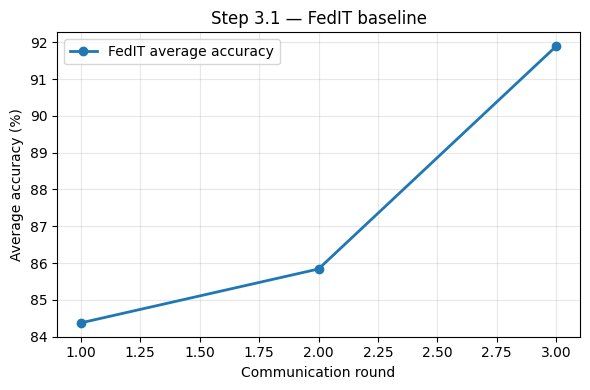

FedIT final client accuracies:
Client 0 (SST-2): 93.36%
Client 1 (SST-2): 93.75%
Client 2 (QNLI): 89.84%
Client 3 (QNLI): 90.62%
FedIT final average accuracy: 91.89%


In [ ]:
# Step 3.1 — FedIT baseline
# variables/functions:
# - client_loaders
# - model
# - device
# - RANK, LORA_ALPHA, LR, NUM_CLIENTS, NUM_LAYERS
# - initialize_lora_params(...)
# - train_client(...)
# - lora_forward(...)

from transformers import AutoTokenizer

if 'tokenizer' not in globals():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if 'MAX_LENGTH' not in globals():
    MAX_LENGTH = 128

print("Tokenizer loaded:", MODEL_NAME)
print("MAX_LENGTH:", MAX_LENGTH)

# ── Step 3.1 | Cell 1 — Create validation loaders ────────────────────────────

from datasets import load_dataset
from torch.utils.data import DataLoader

VAL_SAMPLES_PER_CLIENT = 256  # Keep small for fast evaluation on Colab.


def get_label_column_name(dataset):
    """Return the label column name used by the dataset."""
    if 'label' in dataset.column_names:
        return 'label'
    if 'labels' in dataset.column_names:
        return 'labels'
    raise ValueError(f"No label column found. Columns are: {dataset.column_names}")


def tokenize_sst2_batch(batch):
    """Tokenize SST-2 validation examples."""
    return tokenizer(
        batch['sentence'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    )


def tokenize_qnli_batch(batch):
    """Tokenize QNLI validation examples."""
    return tokenizer(
        batch['question'],
        batch['sentence'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    )


def prepare_validation_dataset(raw_dataset, tokenize_fn):
    """Tokenize a raw validation split and keep only tensors needed by the model."""
    label_col = get_label_column_name(raw_dataset)

    tokenized = raw_dataset.map(tokenize_fn, batched=True)

    if label_col != 'label':
        tokenized = tokenized.rename_column(label_col, 'label')

    keep_columns = ['input_ids', 'attention_mask', 'label']
    remove_columns = [c for c in tokenized.column_names if c not in keep_columns]
    tokenized = tokenized.remove_columns(remove_columns)
    tokenized.set_format(type='torch', columns=keep_columns)

    return tokenized


def make_client_partitions(dataset, num_clients, max_samples_per_client=None, seed=42):
    """Split a Hugging Face dataset into client subsets."""
    dataset = dataset.shuffle(seed=seed)

    if max_samples_per_client is not None:
        total_needed = num_clients * max_samples_per_client
        dataset = dataset.select(range(min(total_needed, len(dataset))))

    partitions = []
    n = len(dataset)
    base_size = n // num_clients

    for cid in range(num_clients):
        start = cid * base_size
        end = (cid + 1) * base_size if cid < num_clients - 1 else n
        partitions.append(dataset.select(range(start, end)))

    return partitions


raw_sst2_validation = load_dataset('glue', 'sst2', split='validation')
raw_qnli_validation = load_dataset('glue', 'qnli', split='validation')

sst2_validation = prepare_validation_dataset(raw_sst2_validation, tokenize_sst2_batch)
qnli_validation = prepare_validation_dataset(raw_qnli_validation, tokenize_qnli_batch)

sst2_val_partitions = make_client_partitions(
    sst2_validation,
    num_clients=2,
    max_samples_per_client=VAL_SAMPLES_PER_CLIENT,
    seed=123
)

qnli_val_partitions = make_client_partitions(
    qnli_validation,
    num_clients=2,
    max_samples_per_client=VAL_SAMPLES_PER_CLIENT,
    seed=456
)

client_eval_datasets = {
    0: sst2_val_partitions[0],
    1: sst2_val_partitions[1],
    2: qnli_val_partitions[0],
    3: qnli_val_partitions[1],
}

client_eval_loaders = {}
for cid, ds in client_eval_datasets.items():
    client_eval_loaders[cid] = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)

print("Validation batches per client:")
for cid, loader in client_eval_loaders.items():
    print(f"  Client {cid} ({task_names[cid]}): {len(loader)} batches")

print("\nValidation sets reloaded and tokenized:")
print("  SST-2 validation size:", len(sst2_validation))
print("  QNLI validation size:", len(qnli_validation))


# ── Step 3.1 | Cell 2 — FedIT helper functions ───────────────────────────────
# FedIT: one shared LoRA module is trained through federated averaging.
# Each client starts from the same global LoRA, trains locally, then the server
# averages all client LoRA parameters.


def clone_lora_params(lora_params):
    """Deep-copy LoRA parameters while detaching them from old computation graphs."""
    cloned = {}

    for key, params in lora_params.items():
        cloned[key] = {
            'A': params['A'].detach().clone().to(device),
            'B': params['B'].detach().clone().to(device),
        }

    return cloned


def average_lora_params(client_states):
    """Average LoRA A and B matrices across all clients."""
    avg_params = {}
    keys = client_states[0].keys()

    for key in keys:
        avg_A = torch.stack([
            state[key]['A'].detach().to(device) for state in client_states
        ], dim=0).mean(dim=0)

        avg_B = torch.stack([
            state[key]['B'].detach().to(device) for state in client_states
        ], dim=0).mean(dim=0)

        avg_params[key] = {
            'A': avg_A,
            'B': avg_B,
        }

    return avg_params


@torch.no_grad()
def evaluate_lora_params(model, lora_params, loader):
    """Evaluate one LoRA parameter set on one client validation loader."""
    model.eval()

    correct = 0
    total = 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        logits = lora_forward(
            model=model,
            input_ids=input_ids,
            attention_mask=attention_mask,
            lora_params=lora_params
        )

        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total if total > 0 else 0.0


def evaluate_fedit_global(model, global_lora_params, eval_loaders):
    """Evaluate the current FedIT global LoRA on all clients."""
    accuracies = []

    for cid in range(NUM_CLIENTS):
        acc = evaluate_lora_params(
            model=model,
            lora_params=global_lora_params,
            loader=eval_loaders[cid]
        )
        accuracies.append(acc)
        print(f"Client {cid} ({task_names[cid]}) accuracy: {acc * 100:.2f}%")

    avg_acc = float(np.mean(accuracies))
    print(f"Average accuracy: {avg_acc * 100:.2f}%")

    return accuracies, avg_acc


# ── Step 3.1 | Cell 3 — FedIT training loop ───────────────────────────────────


def run_fedit(model, train_loaders, eval_loaders, num_rounds=3, local_epochs=1, lr=LR):
    """Run FedIT on the current 4-client setting."""
    print("Starting FedIT baseline")

    # FedIT starts with one shared LoRA module.
    global_lora_params = initialize_lora_params(rank=RANK)

    history = {
        'round': [],
        'client_accuracies': [],
        'average_accuracy': [],
    }

    for round_id in range(1, num_rounds + 1):
        print(f"\n========== FedIT round {round_id}/{num_rounds} ==========")

        local_states = []

        for cid in range(NUM_CLIENTS):
            print(f"\nTraining client {cid} ({task_names[cid]})")

            # Each client receives the same global LoRA at the start of the round.
            local_lora_params = clone_lora_params(global_lora_params)

            local_lora_params, _ = train_client(
                model=model,
                lora_params=local_lora_params,
                loader=train_loaders[cid],
                num_epochs=local_epochs,
                lr=lr
            )

            local_states.append(clone_lora_params(local_lora_params))

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        # Server-side FedAvg over all local LoRA parameters.
        global_lora_params = average_lora_params(local_states)

        print(f"\nEvaluating FedIT global LoRA after round {round_id}")
        client_accs, avg_acc = evaluate_fedit_global(
            model=model,
            global_lora_params=global_lora_params,
            eval_loaders=eval_loaders
        )

        history['round'].append(round_id)
        history['client_accuracies'].append(client_accs)
        history['average_accuracy'].append(avg_acc)

    return global_lora_params, history


# ── Step 3.1 | Cell 4 — Run FedIT ─────────────────────────────────────────────
# Start small. If it works, you can increase FEDIT_ROUNDS later.

FEDIT_ROUNDS = 3
FEDIT_LOCAL_EPOCHS = 1

fedit_global_lora_params, fedit_history = run_fedit(
    model=model,
    train_loaders=client_loaders,
    eval_loaders=client_eval_loaders,
    num_rounds=FEDIT_ROUNDS,
    local_epochs=FEDIT_LOCAL_EPOCHS,
    lr=LR
)


# ── Step 3.1 | Cell 5 — Plot FedIT average accuracy ───────────────────────────

plt.figure(figsize=(6, 4))
plt.plot(
    fedit_history['round'],
    [acc * 100 for acc in fedit_history['average_accuracy']],
    marker='o',
    linewidth=2,
    label='FedIT average accuracy'
)
plt.xlabel('Communication round')
plt.ylabel('Average accuracy (%)')
plt.title('Step 3.1 — FedIT baseline')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('step3_1_fedit_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Step 3.1 | Cell 6 — Save final FedIT results for Figure 2 later ───────────

fedit_final_client_accuracies = fedit_history['client_accuracies'][-1]
fedit_final_average_accuracy = fedit_history['average_accuracy'][-1]

print('FedIT final client accuracies:')
for cid, acc in enumerate(fedit_final_client_accuracies):
    print(f"Client {cid} ({task_names[cid]}): {acc * 100:.2f}%")

print(f"FedIT final average accuracy: {fedit_final_average_accuracy * 100:.2f}%")


Starting simplified FedLoRA-MoE baseline

========== FedLoRA-MoE round 1/3 ==========

Training expert 0 on client 0 (SST-2)
  Epoch 1/1 | Loss: 0.5075

Training expert 1 on client 1 (SST-2)
  Epoch 1/1 | Loss: 0.5076

Training expert 2 on client 2 (QNLI)
  Epoch 1/1 | Loss: 0.5776

Training expert 3 on client 3 (QNLI)
  Epoch 1/1 | Loss: 0.5704

Evaluating simplified FedLoRA-MoE after round 1
Client 0 (SST-2) MoE accuracy: 94.14%
  Single expert accuracies: E0:94.5%, E1:92.2%, E2:52.3%, E3:54.3%
  MoE weights: E0:0.55, E1:0.43, E2:0.01, E3:0.01
Client 1 (SST-2) MoE accuracy: 92.97%
  Single expert accuracies: E0:93.0%, E1:92.2%, E2:50.0%, E3:53.9%
  MoE weights: E0:0.51, E1:0.47, E2:0.01, E3:0.01
Client 2 (QNLI) MoE accuracy: 90.62%
  Single expert accuracies: E0:53.1%, E1:51.6%, E2:90.6%, E3:89.8%
  MoE weights: E0:0.01, E1:0.01, E2:0.51, E3:0.47
Client 3 (QNLI) MoE accuracy: 87.89%
  Single expert accuracies: E0:53.9%, E1:51.2%, E2:85.5%, E3:88.3%
  MoE weights: E0:0.02, E1:0.01, E2

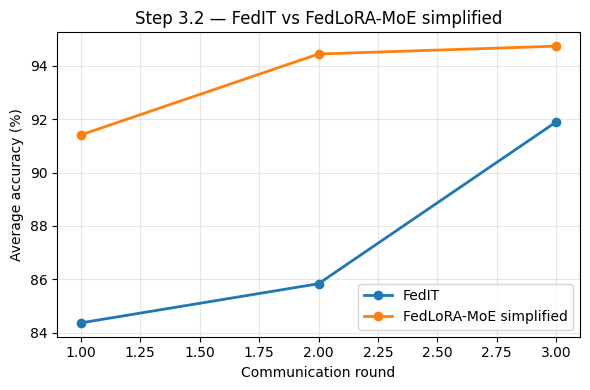

Simplified FedLoRA-MoE final client accuracies:
Client 0 (SST-2): 95.31%
Client 1 (SST-2): 94.92%
Client 2 (QNLI): 94.92%
Client 3 (QNLI): 93.75%
Simplified FedLoRA-MoE final average accuracy: 94.73%


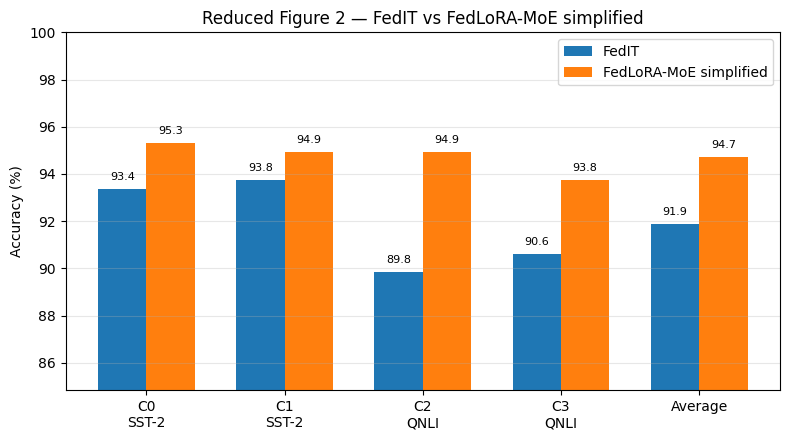

In [ ]:
# Step 3.2 — FedLoRA-MoE simplified baseline

# ── Step 3.2 | 1 — FedLoRA-MoE helper functions ─────────────────────────
# Simplified FedLoRA-MoE idea:
# - Each client trains its own LoRA expert.
# - Experts are NOT averaged by the server.
# - At evaluation time, each client combines the outputs of all experts.
#
# This is a simplified reproduction of the paper's FedLoRA-MoE motivation.
# It does not yet train a router; instead, it uses a simple fixed weighting rule.


def softmax_numpy(x):
    """Small NumPy softmax helper."""
    x = np.array(x, dtype=np.float64)
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / exp_x.sum()


@torch.no_grad()
def evaluate_single_expert_on_loader(model, expert_params, loader):
    """Evaluate one LoRA expert on one validation loader."""
    model.eval()

    correct = 0
    total = 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        logits = lora_forward(
            model=model,
            input_ids=input_ids,
            attention_mask=attention_mask,
            lora_params=expert_params
        )

        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total if total > 0 else 0.0


@torch.no_grad()
def evaluate_moe_on_loader(model, expert_params_list, loader, expert_weights):
    """Evaluate a fixed-weight LoRA-MoE on one validation loader."""
    model.eval()

    correct = 0
    total = 0

    # Convert weights once.
    weights = torch.tensor(expert_weights, dtype=torch.float32, device=device)

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        mixed_logits = None

        for expert_id, expert_params in enumerate(expert_params_list):
            logits = lora_forward(
                model=model,
                input_ids=input_ids,
                attention_mask=attention_mask,
                lora_params=expert_params
            )

            weighted_logits = weights[expert_id] * logits

            if mixed_logits is None:
                mixed_logits = weighted_logits
            else:
                mixed_logits = mixed_logits + weighted_logits

        preds = mixed_logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total if total > 0 else 0.0


def compute_client_expert_weights(model, expert_params_list, eval_loader, temperature=10.0):
    """Compute fixed MoE weights for one client based on expert validation accuracy.

    This replaces the trainable router with a simple and transparent proxy:
    experts that perform better on the client's validation subset receive larger weights.
    """
    expert_accs = []

    for expert_id, expert_params in enumerate(expert_params_list):
        acc = evaluate_single_expert_on_loader(
            model=model,
            expert_params=expert_params,
            loader=eval_loader
        )
        expert_accs.append(acc)

    # Temperature sharpens the preference for the best experts.
    weights = softmax_numpy(np.array(expert_accs) * temperature)

    return expert_accs, weights


# ── Step 3.2 | 2 — FedLoRA-MoE training loop ─────────────────────────────


def run_fedlora_moe_simplified(model, train_loaders, eval_loaders, num_rounds=3, local_epochs=1, lr=LR):
    """Run a simplified FedLoRA-MoE baseline.

    Unlike FedIT, this method does not average the LoRA modules.
    Each client keeps its own expert across rounds.
    """
    print("Starting simplified FedLoRA-MoE baseline")

    # One expert per client.
    expert_params_list = [initialize_lora_params(rank=RANK) for _ in range(NUM_CLIENTS)]

    history = {
        'round': [],
        'client_accuracies': [],
        'average_accuracy': [],
        'expert_weights': [],
        'expert_single_accuracies': [],
    }

    for round_id in range(1, num_rounds + 1):
        print(f"\n========== FedLoRA-MoE round {round_id}/{num_rounds} ==========")

        # Local update: each client updates only its own LoRA expert.
        for cid in range(NUM_CLIENTS):
            print(f"\nTraining expert {cid} on client {cid} ({task_names[cid]})")

            local_expert = clone_lora_params(expert_params_list[cid])

            local_expert, _ = train_client(
                model=model,
                lora_params=local_expert,
                loader=train_loaders[cid],
                num_epochs=local_epochs,
                lr=lr
            )

            expert_params_list[cid] = clone_lora_params(local_expert)

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        # Evaluation: each client combines all experts with fixed validation-based weights.
        print(f"\nEvaluating simplified FedLoRA-MoE after round {round_id}")

        client_accs = []
        round_weights = []
        round_single_accs = []

        for cid in range(NUM_CLIENTS):
            expert_accs, weights = compute_client_expert_weights(
                model=model,
                expert_params_list=expert_params_list,
                eval_loader=eval_loaders[cid],
                temperature=10.0
            )

            moe_acc = evaluate_moe_on_loader(
                model=model,
                expert_params_list=expert_params_list,
                loader=eval_loaders[cid],
                expert_weights=weights
            )

            client_accs.append(moe_acc)
            round_weights.append(weights)
            round_single_accs.append(expert_accs)

            weights_str = ", ".join([f"E{eid}:{w:.2f}" for eid, w in enumerate(weights)])
            single_accs_str = ", ".join([f"E{eid}:{a * 100:.1f}%" for eid, a in enumerate(expert_accs)])

            print(f"Client {cid} ({task_names[cid]}) MoE accuracy: {moe_acc * 100:.2f}%")
            print(f"  Single expert accuracies: {single_accs_str}")
            print(f"  MoE weights: {weights_str}")

        avg_acc = float(np.mean(client_accs))
        print(f"Average MoE accuracy: {avg_acc * 100:.2f}%")

        history['round'].append(round_id)
        history['client_accuracies'].append(client_accs)
        history['average_accuracy'].append(avg_acc)
        history['expert_weights'].append(round_weights)
        history['expert_single_accuracies'].append(round_single_accs)

    return expert_params_list, history


# ── Step 3.2 | 3 — Run simplified FedLoRA-MoE ────────────────────────────
# Keep the same number of rounds as FedIT for a fair first comparison.

MOE_ROUNDS = 3
MOE_LOCAL_EPOCHS = 1

moe_expert_params_list, moe_history = run_fedlora_moe_simplified(
    model=model,
    train_loaders=client_loaders,
    eval_loaders=client_eval_loaders,
    num_rounds=MOE_ROUNDS,
    local_epochs=MOE_LOCAL_EPOCHS,
    lr=LR
)


# ── Step 3.2 | 4 — Plot FedIT vs simplified FedLoRA-MoE learning curves ──

plt.figure(figsize=(6, 4))

plt.plot(
    fedit_history['round'],
    [acc * 100 for acc in fedit_history['average_accuracy']],
    marker='o',
    linewidth=2,
    label='FedIT'
)

plt.plot(
    moe_history['round'],
    [acc * 100 for acc in moe_history['average_accuracy']],
    marker='o',
    linewidth=2,
    label='FedLoRA-MoE simplified'
)

plt.xlabel('Communication round')
plt.ylabel('Average accuracy (%)')
plt.title('Step 3.2 — FedIT vs FedLoRA-MoE simplified')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('step3_2_fedit_vs_moe_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Step 3.2 | 5 — Save final MoE results for Figure 2 later ─────────────

moe_final_client_accuracies = moe_history['client_accuracies'][-1]
moe_final_average_accuracy = moe_history['average_accuracy'][-1]

print('Simplified FedLoRA-MoE final client accuracies:')
for cid, acc in enumerate(moe_final_client_accuracies):
    print(f"Client {cid} ({task_names[cid]}): {acc * 100:.2f}%")

print(f"Simplified FedLoRA-MoE final average accuracy: {moe_final_average_accuracy * 100:.2f}%")


# ── Step 3.2 | 6 — Reduced Figure 2 bar plot ─────────────────────────────
# This prepares a 4-client version of Figure 2.

labels = [f'C{cid}\n{task_names[cid]}' for cid in range(NUM_CLIENTS)] + ['Average']

fedit_scores = [acc * 100 for acc in fedit_final_client_accuracies] + [fedit_final_average_accuracy * 100]
moe_scores = [acc * 100 for acc in moe_final_client_accuracies] + [moe_final_average_accuracy * 100]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 4.5))
plt.bar(x - width / 2, fedit_scores, width, label='FedIT')
plt.bar(x + width / 2, moe_scores, width, label='FedLoRA-MoE simplified')

plt.ylabel('Accuracy (%)')
plt.title('Reduced Figure 2 — FedIT vs FedLoRA-MoE simplified')
plt.xticks(x, labels)
plt.ylim(max(0, min(fedit_scores + moe_scores) - 5), 100)
plt.grid(axis='y', alpha=0.3)
plt.legend()

for i, value in enumerate(fedit_scores):
    plt.text(i - width / 2, value + 0.3, f'{value:.1f}', ha='center', va='bottom', fontsize=8)

for i, value in enumerate(moe_scores):
    plt.text(i + width / 2, value + 0.3, f'{value:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('step3_2_reduced_figure2.png', dpi=150, bbox_inches='tight')
plt.show()
